In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zkskhurram/blood-pressure-by-age-global-dataset/country_bp_summary.csv
/kaggle/input/datasets/zkskhurram/blood-pressure-by-age-global-dataset/blood_pressure_global_dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/zkskhurram/blood-pressure-by-age-global-dataset/blood_pressure_global_dataset.csv")

In [3]:
df.head()

,Patient_ID,Year,Country,WHO_Region,Income_Level,Currency,ISO2_Country_Code,Age,Age_Group,Sex,...,BP_Category,Is_Hypertensive,Hypertension_Aware,On_Treatment,BP_Controlled,Country_HTN_Prevalence_pct,Measurement_Time,Measurement_Arm,Measurement_Setting,Measurement_Device
0,BP-00001,2000,Papua New Guinea,Western Pacific,Lower-Middle Income,PGK,pg,34,Adult (30-39),Male,...,Normal,0,NaN,No,No,38,Morning,Right,Home,Mercury Sphygmomanometer
1,BP-00002,2022,Uganda,Africa,Low Income,UGX,ug,3,Early Childhood (1-5),Female,...,Hypotension (Low),0,NaN,No,No,47,Morning,Left,Pharmacy,Wrist Digital
2,BP-00003,2024,Kenya,Africa,Lower-Middle Income,KES,ke,29,Young Adult (19-29),Male,...,Elevated,0,NaN,No,No,42,Morning,Right,Clinical/Hospital,Automated Oscillometric
3,BP-00004,2014,Thailand,South-East Asia,Upper-Middle Income,THB,th,53,Middle-Aged Senior (50-59),Male,...,Hypertension Stage 2,1,No,No,No,32,Afternoon,Right,Community Screening,Automated Oscillometric
4,BP-00005,2001,India,South-East Asia,Lower-Middle Income,INR,in,11,Early Adolescence (11-15),Female,...,Normal,0,NaN,No,No,29,Evening,Right,Home,Automated Oscillometric


In [4]:
df.shape

(8000, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  8000 non-null   object 
 1   Year                        8000 non-null   int64  
 2   Country                     8000 non-null   object 
 3   WHO_Region                  8000 non-null   object 
 4   Income_Level                8000 non-null   object 
 5   Currency                    8000 non-null   object 
 6   ISO2_Country_Code           8000 non-null   object 
 7   Age                         8000 non-null   int64  
 8   Age_Group                   8000 non-null   object 
 9   Sex                         8000 non-null   object 
 10  BMI                         8000 non-null   float64
 11  BMI_Category                8000 non-null   object 
 12  Smoking_Status              8000 non-null   object 
 13  Alcohol_Use                 3748 

In [6]:
df.describe()

,Year,Age,BMI,Systolic_BP_mmHg,Diastolic_BP_mmHg,Pulse_Pressure_mmHg,Mean_Arterial_Pressure,Heart_Rate_bpm,Is_Hypertensive,Country_HTN_Prevalence_pct
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2015.723000,39.993875,24.540563,125.766112,75.824762,49.941350,92.471587,82.559500,0.544000,34.499500
std,6.814109,22.103295,5.409343,22.910090,13.085791,18.602468,14.568163,14.084841,0.498091,5.896575
min,2000.000000,0.000000,13.000000,49.500000,27.500000,0.700000,41.000000,40.000000,0.000000,24.000000
25%,2011.000000,23.000000,20.500000,112.000000,67.300000,36.900000,84.200000,73.000000,0.000000,30.000000
50%,2017.000000,40.000000,24.300000,126.400000,76.300000,48.600000,93.600000,82.000000,1.000000,35.000000
75%,2021.000000,56.000000,28.300000,140.800000,84.800000,61.600000,102.400000,91.000000,1.000000,38.000000
max,2025.000000,110.000000,44.600000,230.400000,128.000000,138.400000,144.100000,147.000000,1.000000,48.000000


Dataset Overview

The dataset contains global blood pressure measurements across different age groups and demographic characteristics. It allows us to analyze how blood pressure trends change with age and other factors.

In [7]:
df.isnull().sum()

Patient_ID                       0
Year                             0
Country                          0
WHO_Region                       0
Income_Level                     0
Currency                         0
ISO2_Country_Code                0
Age                              0
Age_Group                        0
Sex                              0
BMI                              0
BMI_Category                     0
Smoking_Status                   0
Alcohol_Use                   4252
Physical_Activity                0
Diet_Salt_Intake                 0
Stress_Level                     0
Diabetes                         0
Family_Hx_Hypertension           0
Systolic_BP_mmHg                 0
Diastolic_BP_mmHg                0
Pulse_Pressure_mmHg              0
Mean_Arterial_Pressure           0
Heart_Rate_bpm                   0
BP_Category                      0
Is_Hypertensive                  0
Hypertension_Aware            3648
On_Treatment                     0
BP_Controlled       

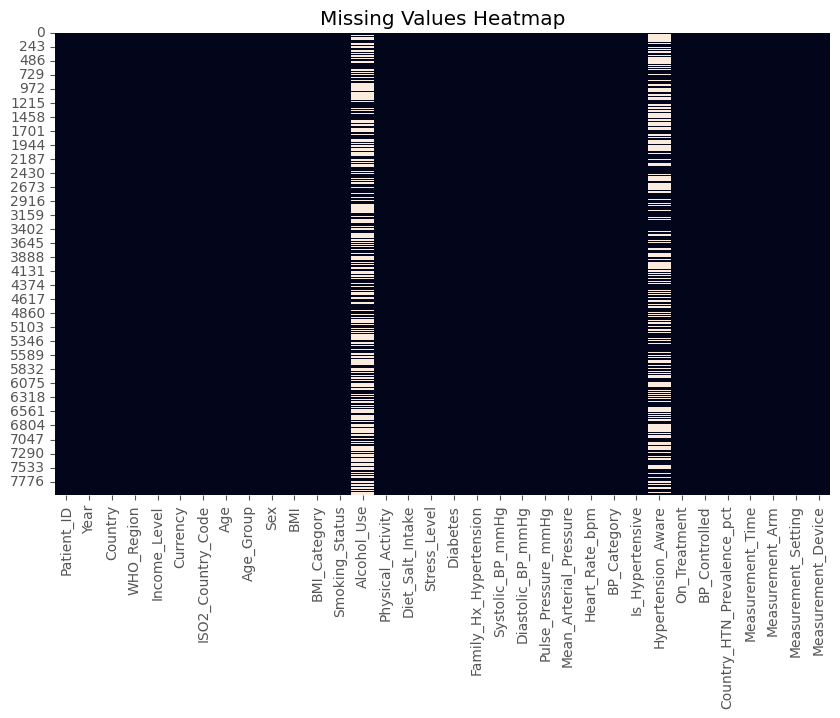

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

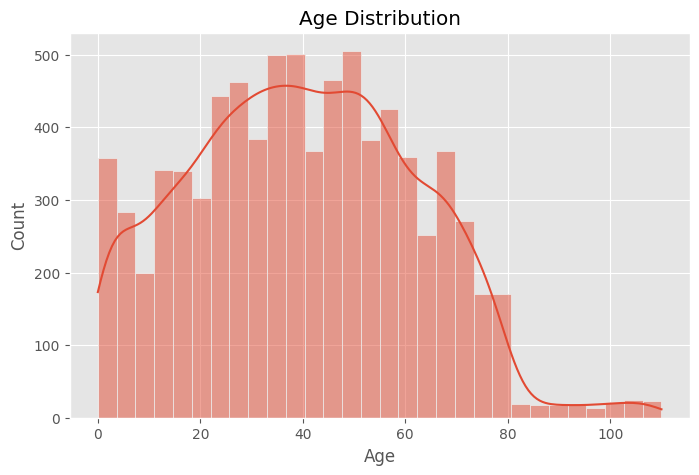

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Most individuals in the dataset fall within the middle-age group, suggesting that the dataset focuses heavily on adult populations.

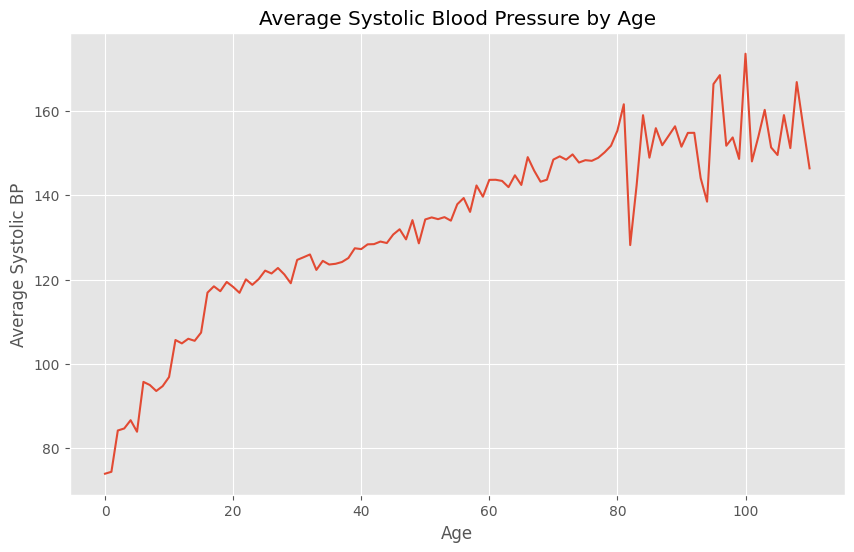

In [10]:
age_bp = df.groupby("Age")["Systolic_BP_mmHg"].mean()

plt.figure(figsize=(10,6))
plt.plot(age_bp)

plt.title("Average Systolic Blood Pressure by Age")
plt.xlabel("Age")
plt.ylabel("Average Systolic BP")

plt.show()

Average systolic blood pressure tends to increase with age, which aligns with medical research indicating that hypertension risk rises in older populations.

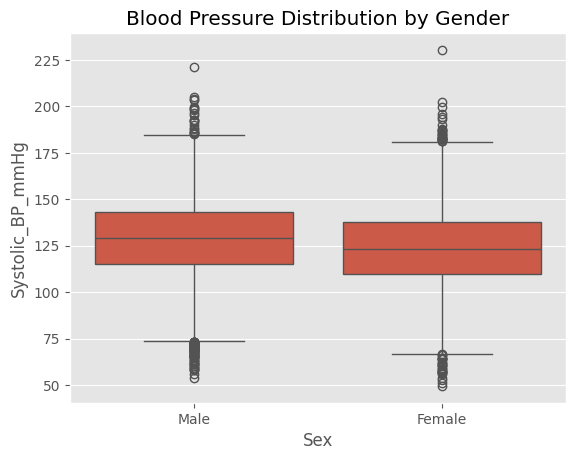

In [11]:
sns.boxplot(data=df, x="Sex", y="Systolic_BP_mmHg")

plt.title("Blood Pressure Distribution by Gender")

plt.show()

Blood pressure distribution varies slightly between genders, which may reflect physiological and lifestyle differences.

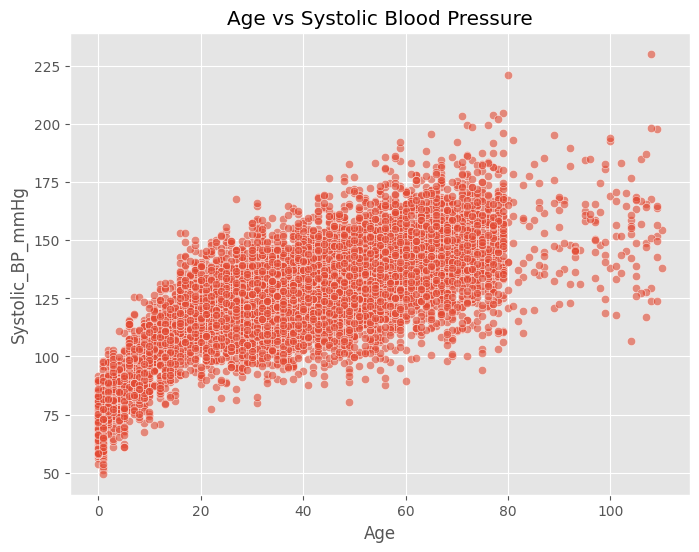

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Age", y="Systolic_BP_mmHg", alpha=0.6)

plt.title("Age vs Systolic Blood Pressure")

plt.show()

The scatter plot suggests a positive correlation between age and blood pressure.

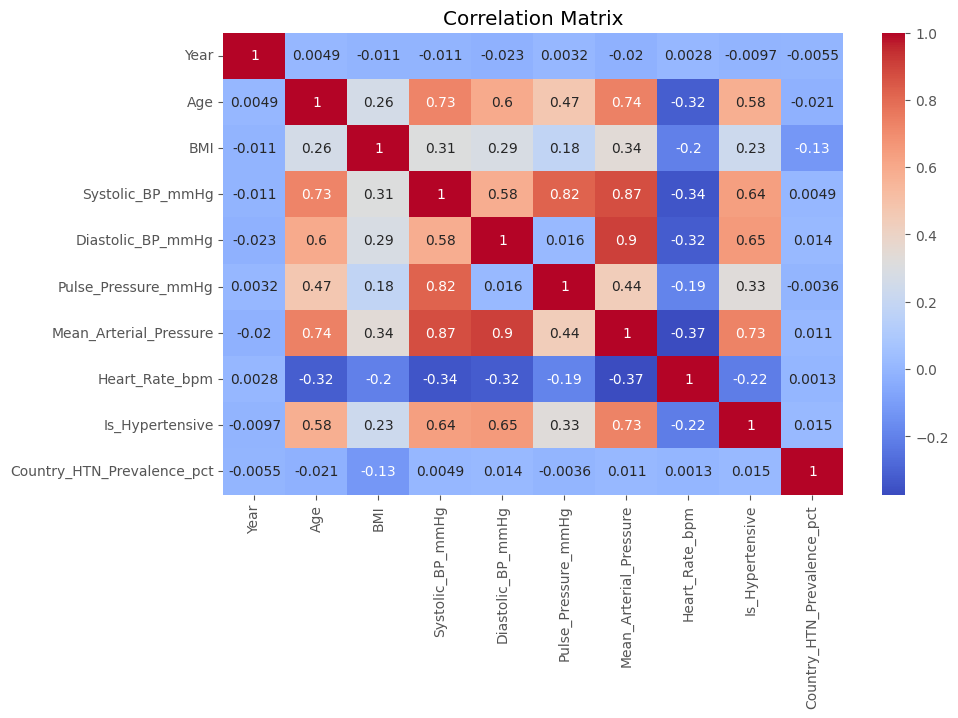

In [13]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Correlation analysis helps identify which factors are most strongly associated with blood pressure levels.

Conclusion

This exploratory analysis highlights important patterns in the dataset:

Blood pressure generally increases with age.
There are observable differences between demographic groups.
Several health indicators show correlations with blood pressure levels.

These insights can support further research in cardiovascular health and hypertension risk analysis.